In [1]:
# TODO обработать adult и air quality
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

Начальная обработка данных.

In [2]:
# загрузка данных
df_house = pd.read_csv('../data/raw/housing.csv')
df_adult = pd.read_csv('../data/raw/adult.csv')
df_air = pd.read_csv('../data/raw/AirQuality.csv', sep=';')

print(f'Количество строк в датасетах. Housing: {len(df_house)}, Adult: {len(df_adult)}, AirQuality: {len(df_air)}.\n')

# удаляем лишние столбцы
df_air = df_air.drop(columns=['Unnamed: 15', 'Unnamed: 16'])

print(f'Количество пропусков.'
      f'Housing: {df_house.isna().sum().sum()}'
      f'\nAdult: {df_adult.isna().sum().sum()}'
      f'\nAirQuality: {df_air.isna().sum().sum()}.')

# удаляем пропуски
df_house = df_house.dropna()
df_adult = df_adult.dropna()
df_air = df_air.dropna()

df_house.to_csv('../data/processed/housing/ground_truth.csv', index=False)
df_adult.to_csv('../data/processed/adult/ground_truth.csv', index=False)
df_air.to_csv('../data/processed/air_quality/ground_truth.csv', index=False)

Количество строк в датасетах. Housing: 20640, Adult: 48842, AirQuality: 9471.

Количество пропусков.Housing: 207
Adult: 0
AirQuality: 1710.


In [3]:
df_air.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


Посмотрим на корреляции.

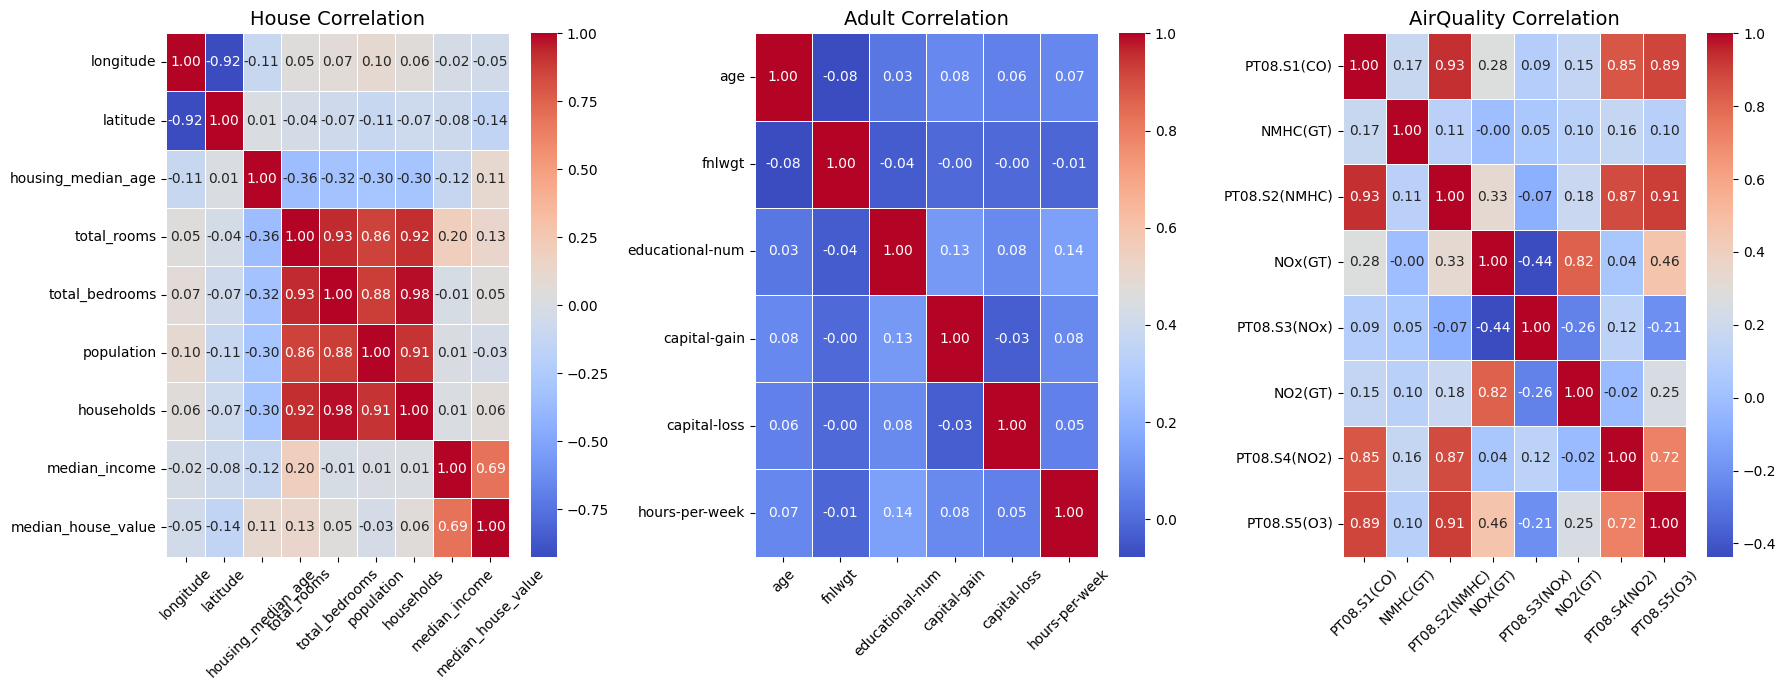

In [4]:
dfs = [
    (df_house.select_dtypes(include='number'), 'House'),
    (df_adult.select_dtypes(include='number'), 'Adult'),
    (df_air.select_dtypes(include='number'), 'AirQuality')
]

fig, axes = plt.subplots(1, len(dfs), figsize=(18, 7))

for ax, (df_numeric, title) in zip(axes, dfs):
    sns.heatmap(
        df_numeric.corr(),
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f'{title} Correlation', fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

Для датасета с ценами на дома будем делать пропуски в столбцу population, так как есть сильная корреляция с другими столбцами, но эта корреляция не 0.97.

In [ ]:
# TODO убрать ячейку после того как решу убирать данные или нет
# берем не все данные
# df_house = df_house.sample(5000)
# df_air = df_air.iloc[-5000:].copy()

# сохраняем обрезанные данные
# df_house.to_csv('../data/processed/housing/ground_truth.csv', index=False)
# df_air.to_csv('../data/processed/air_quality/ground_truth.csv', index=False)